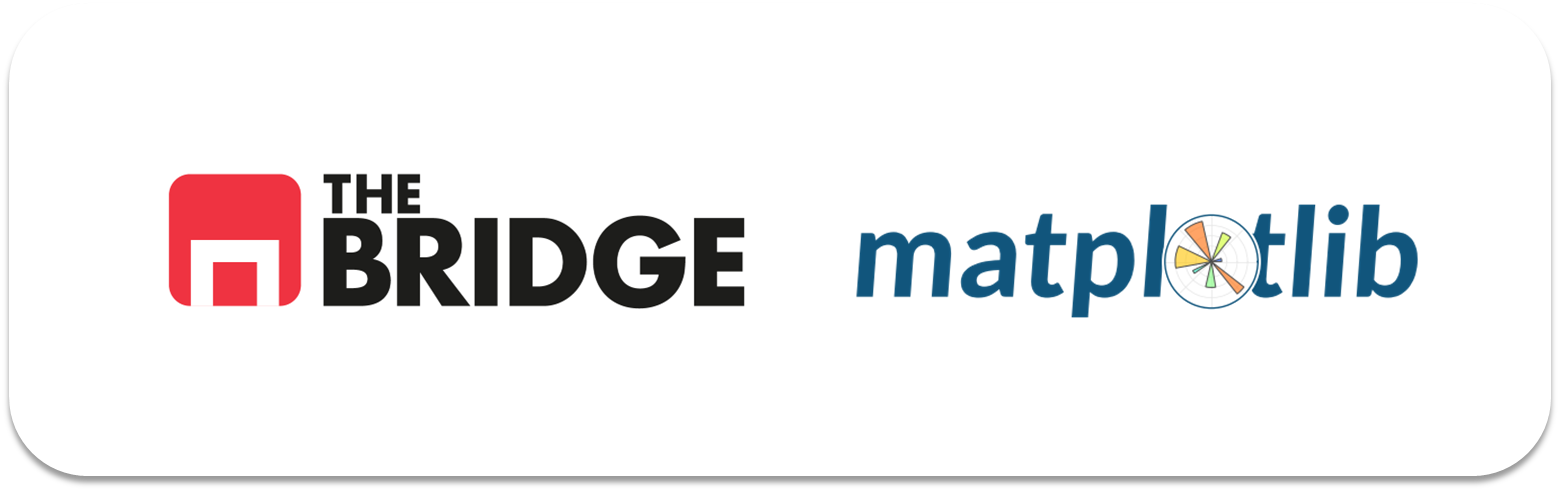

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [2]:
df = pd.read_csv("./data/california_cities.csv")
print(f"Shape original: {df.shape}")
df.head()

Shape original: (482, 14)


,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01


In [3]:
df.describe()

,Unnamed: 0,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
count,482.000000,482.000000,482.000000,434.000000,470.000000,4.820000e+02,480.000000,482.000000,481.000000,477.000000,478.000000,478.000000,477.000000
mean,240.500000,36.095088,-119.837714,180.416705,567.168723,6.489493e+04,18.442183,16.840981,1.589630,46.753283,43.547021,3.125178,5.301801
std,139.285678,2.298006,2.147676,309.531825,1001.265722,2.032041e+05,36.363230,32.694647,9.490386,90.972269,84.933022,11.562269,14.656428
min,0.000000,32.578333,-124.263333,-34.000000,-180.000000,1.000000e+00,0.314000,0.314000,0.000000,0.813000,0.813000,0.000000,0.000000
25%,120.250000,33.977292,-121.954931,22.000000,69.000000,1.090200e+04,3.708250,3.506500,0.000000,9.551000,9.025000,0.000250,0.000000
50%,240.500000,36.204722,-119.708611,67.000000,200.000000,2.905750e+04,9.093000,8.362000,0.029000,23.551000,21.533000,0.078500,0.340000
75%,360.750000,37.886667,-117.977292,173.500000,515.000000,6.646650e+04,19.878250,19.090000,0.244000,51.772000,49.322000,0.623250,1.870000
max,481.000000,41.965000,-114.596389,2402.000000,7880.000000,3.884307e+06,503.000000,469.000000,185.020000,1302.000000,1214.000000,122.270000,84.580000


In [ ]:
print(df.isnull().sum())

Unnamed: 0             0
city                   0
latd                   0
longd                  0
elevation_m           48
elevation_ft          12
population_total       0
area_total_sq_mi       2
area_land_sq_mi        0
area_water_sq_mi       1
area_total_km2         5
area_land_km2          4
area_water_km2         4
area_water_percent     5
dtype: int64


In [6]:
df.dropna()
df.shape

(482, 14)

#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.
4. El boxplot de la altura de las ciudades.

In [9]:
top5 = df.nlargest(5, "population_total").copy()
top5["pop_miles"] = top5["population_total"]/100

ciudades = top5["city"].tolist()
pops_miles = top5["pop_miles"].tolist()
colores    = ['blue', 'gray', 'red', 'olive', 'brown']

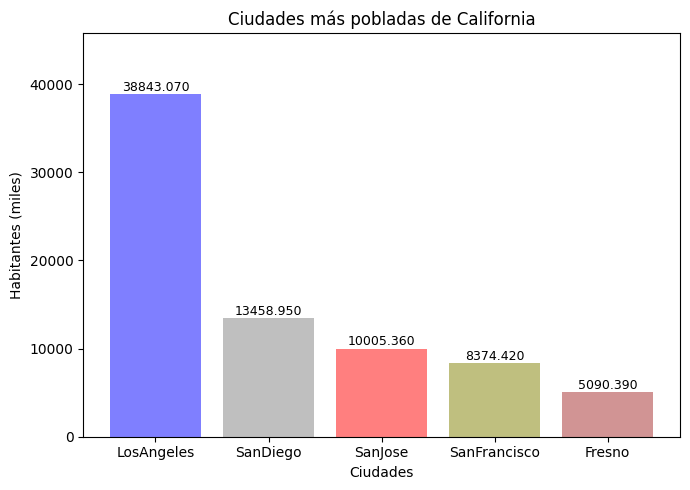

In [10]:
fig1, ax1 = plt.subplots(figsize=(7, 5))

bars = ax1.bar(ciudades, pops_miles, color=colores, alpha=0.5)

# Etiqueta con el valor encima de cada barra
for bar, val in zip(bars, pops_miles):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{val:.3f}',
        ha='center', va='bottom', fontsize=9
    )

ax1.set_title('Ciudades más pobladas de California')
ax1.set_xlabel('Ciudades')
ax1.set_ylabel('Habitantes (miles)')
ax1.set_ylim(0, max(pops_miles) * 1.18)

plt.tight_layout()
plt.show()

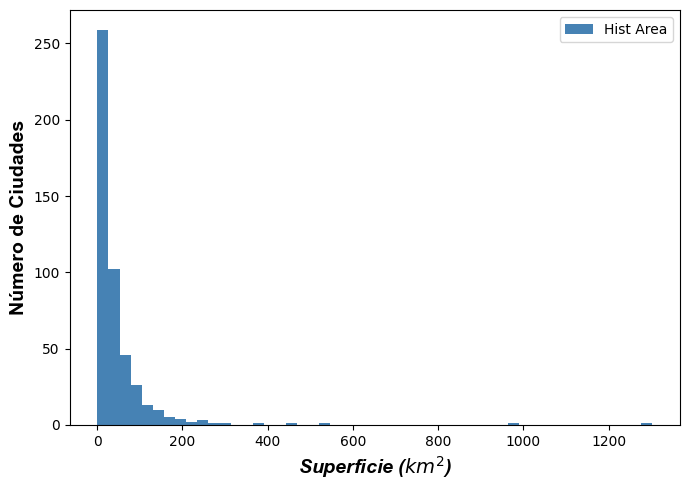

In [11]:
fig2, ax2 = plt.subplots(figsize=(7, 5))

ax2.hist(df['area_total_km2'], bins=50, color='steelblue', label='Hist Area')

ax2.set_xlabel(
    r'Superficie ($km^2$)',
    fontfamily='Arial', fontsize=14, fontweight='bold', style='italic'
)
ax2.set_ylabel(
    'Número de Ciudades',
    fontfamily='Arial', fontsize=14, fontweight='bold'
)
ax2.legend()

plt.tight_layout()
plt.show()

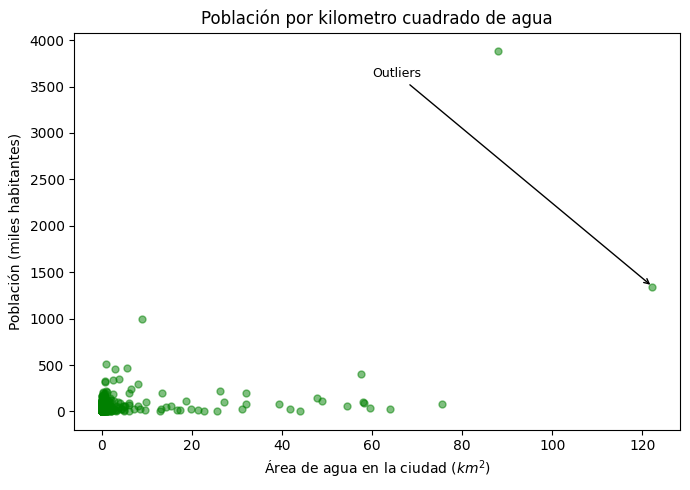

In [12]:
fig3, ax3 = plt.subplots(figsize=(7, 5))

ax3.scatter(
    df['area_water_km2'],
    df['population_total'] / 1000,
    alpha=0.5, color='green', s=25
)

# Anotar el outlier (ciudad con más área de agua)
outlier = df.nlargest(1, 'area_water_km2').iloc[0]
ax3.annotate(
    'Outliers',
    xy=(outlier['area_water_km2'], outlier['population_total'] / 1000),
    xytext=(60, 3600),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9
)

ax3.set_title('Población por kilometro cuadrado de agua')
ax3.set_xlabel(r'Área de agua en la ciudad ($km^2$)')
ax3.set_ylabel('Población (miles habitantes)')

plt.tight_layout()
plt.show()

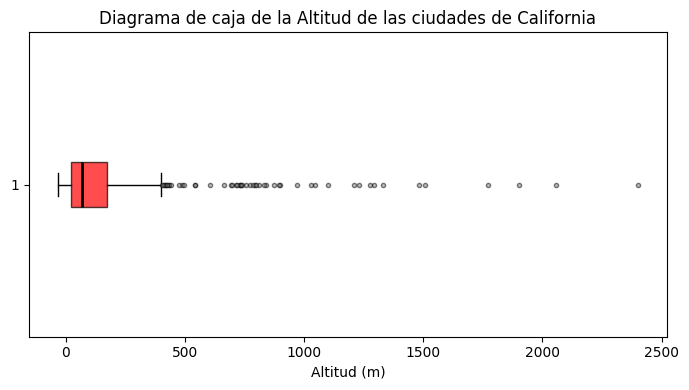

In [13]:
fig4, ax4 = plt.subplots(figsize=(7, 4))

ax4.boxplot(
    df['elevation_m'].dropna(),
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='red', alpha=0.7),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=3, markerfacecolor='gray', alpha=0.5)
)

ax4.set_title('Diagrama de caja de la Altitud de las ciudades de California')
ax4.set_xlabel('Altitud (m)')
ax4.set_yticks([1])
ax4.set_yticklabels(['1'])

plt.tight_layout()
plt.show()

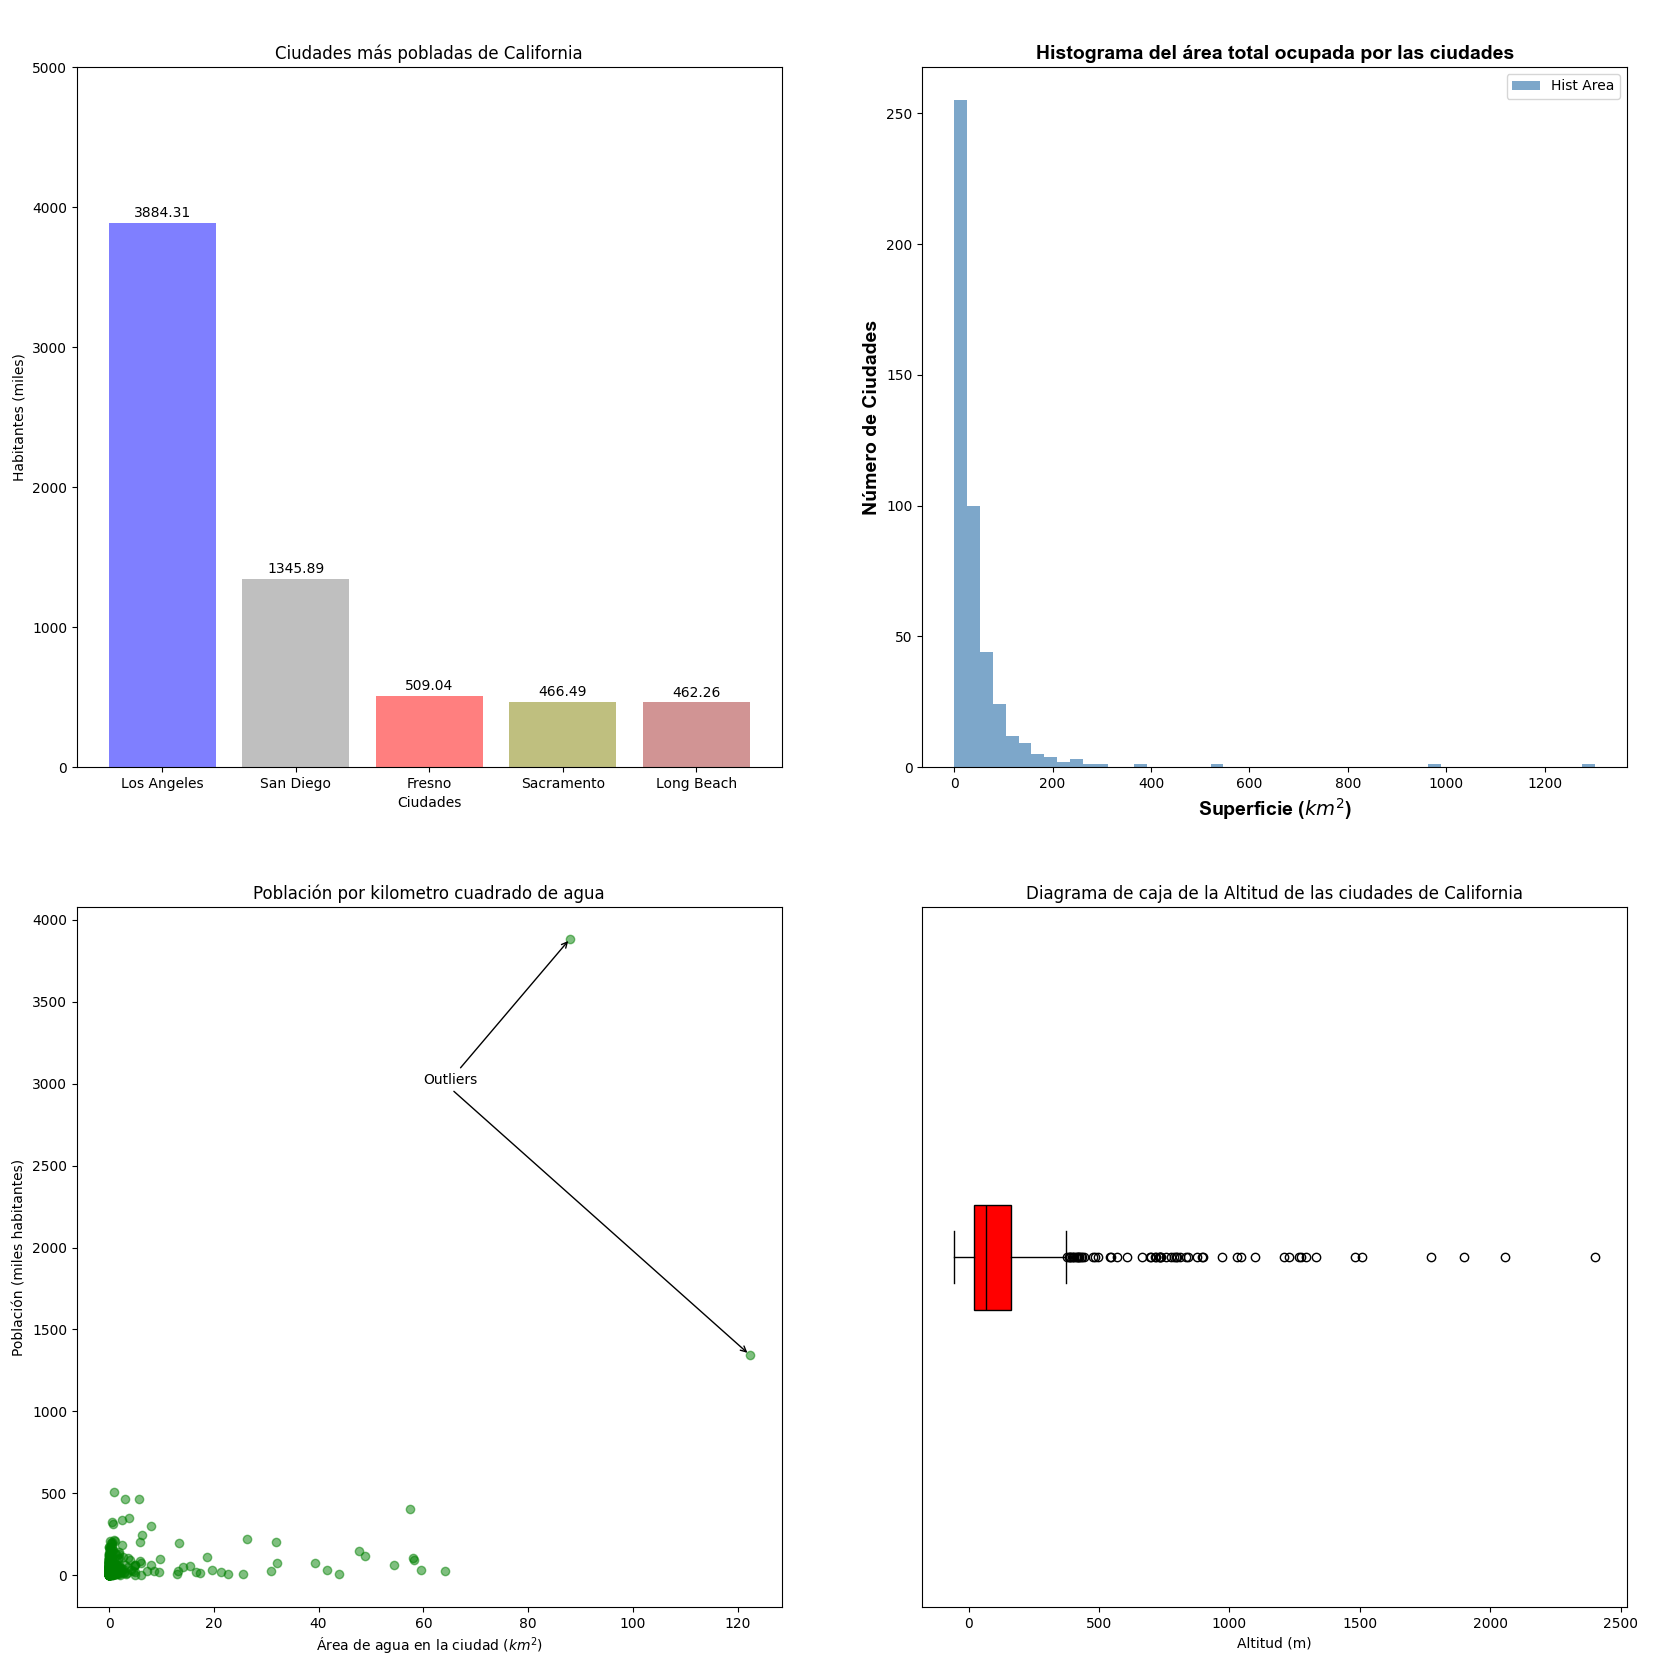

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

Figura guardada como figura_completa.png


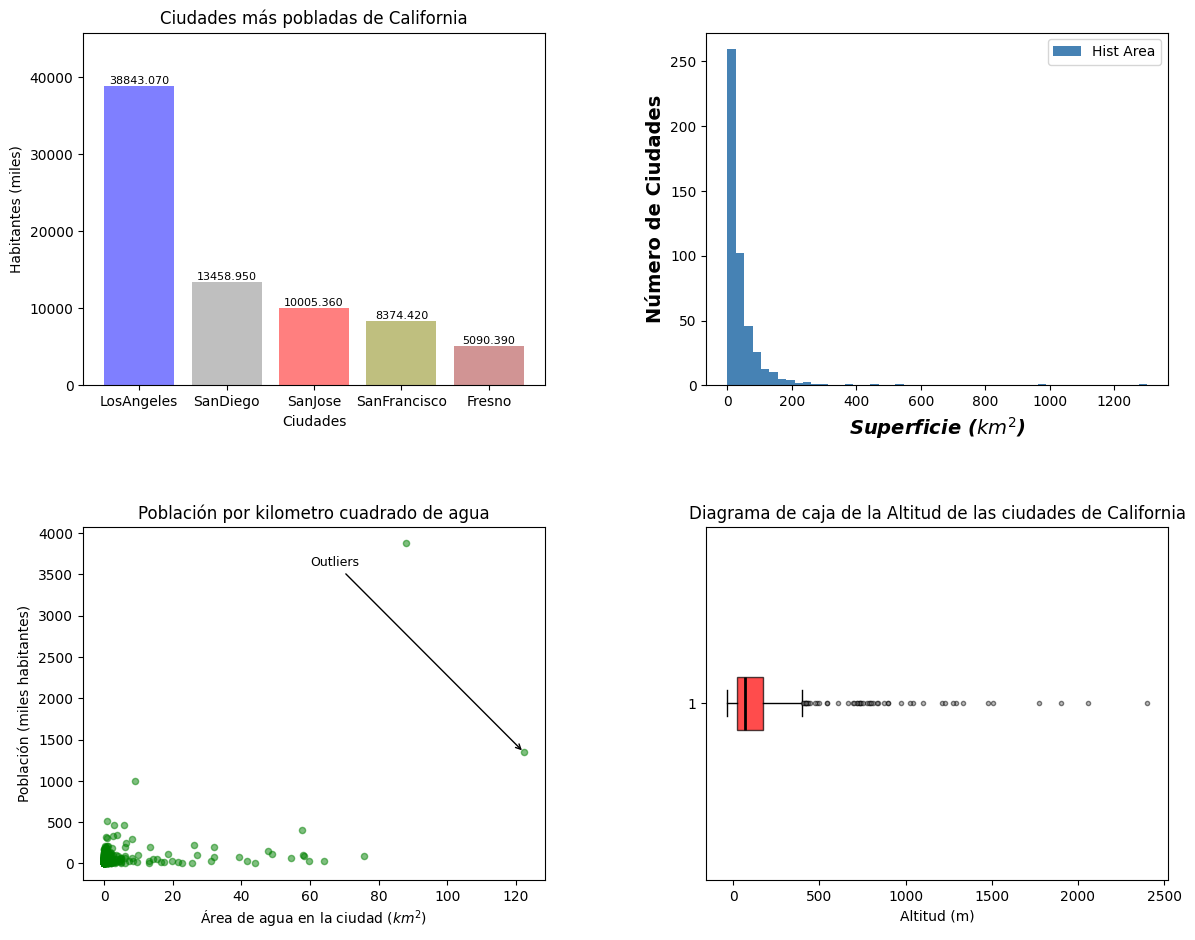

In [14]:
# Regenerar la figura completa y guardarla
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.subplots_adjust(hspace=0.4, wspace=0.35)

ax = axes[0, 0]
bars = ax.bar(ciudades, pops_miles, color=colores, alpha=0.5)
for bar, val in zip(bars, pops_miles):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+30,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_title('Ciudades más pobladas de California')
ax.set_xlabel('Ciudades'); ax.set_ylabel('Habitantes (miles)')
ax.set_ylim(0, max(pops_miles) * 1.18)

ax = axes[0, 1]
ax.hist(df['area_total_km2'], bins=50, color='steelblue', label='Hist Area')
ax.set_xlabel(r'Superficie ($km^2$)', fontsize=14, fontweight='bold', style='italic')
ax.set_ylabel('Número de Ciudades', fontsize=14, fontweight='bold')
ax.legend()

ax = axes[1, 0]
ax.scatter(df['area_water_km2'], df['population_total']/1000,
           alpha=0.5, color='green', s=20)
outlier = df.nlargest(1, 'area_water_km2').iloc[0]
ax.annotate('Outliers', xy=(outlier['area_water_km2'], outlier['population_total']/1000),
            xytext=(60, 3600), arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)
ax.set_title('Población por kilometro cuadrado de agua')
ax.set_xlabel(r'Área de agua en la ciudad ($km^2$)')
ax.set_ylabel('Población (miles habitantes)')

ax = axes[1, 1]
ax.boxplot(df['elevation_m'].dropna(), vert=False, patch_artist=True,
           boxprops=dict(facecolor='red', alpha=0.7),
           medianprops=dict(color='black', linewidth=2),
           flierprops=dict(marker='o', markersize=3, markerfacecolor='gray', alpha=0.5))
ax.set_title('Diagrama de caja de la Altitud de las ciudades de California')
ax.set_xlabel('Altitud (m)')
ax.set_yticks([1]); ax.set_yticklabels(['1'])

fig.savefig('figura_completa.png', dpi=150, bbox_inches='tight')
print("Figura guardada como figura_completa.png")
plt.show()